
1. Итоговая матрица памяти S (сжатый контекст ВСЕГО предложения):
[[-1.39694857  0.68141542  0.14552715  0.90624917]
 [ 1.31907453 -0.33613096  0.22453241 -0.61553596]
 [-5.61178329  1.91142834 -0.14806777  3.57269778]
 [-8.27424464  1.08457608 -1.24316892  6.35967104]]

2. Выходные векторы (предсказания на основе контекста):
[[ 0.          0.          0.          0.        ]
 [-0.98031145  0.19974676 -2.07268184  0.67654805]
 [ 0.95966632 -1.94464958  4.85169734  5.4109193 ]]

3. Значения дельт (ошибок предсказания) для каждого слова:
  Кошка: 1.3321 (длина вектора ошибки)
  ест: 1.9829 (длина вектора ошибки)
  рыбу: 7.8707 (длина вектора ошибки)

4. Значения гейтов:
  (alpha — забывание: 1 = все помнить, 0 =  все забыть)
  (beta — обновление: 1 = сильно обновить, 0 = не обновлять)
  Кошка: alpha=0.730, beta=0.816
  ест: alpha=0.737, beta=0.824
  рыбу: alpha=0.703, beta=0.784


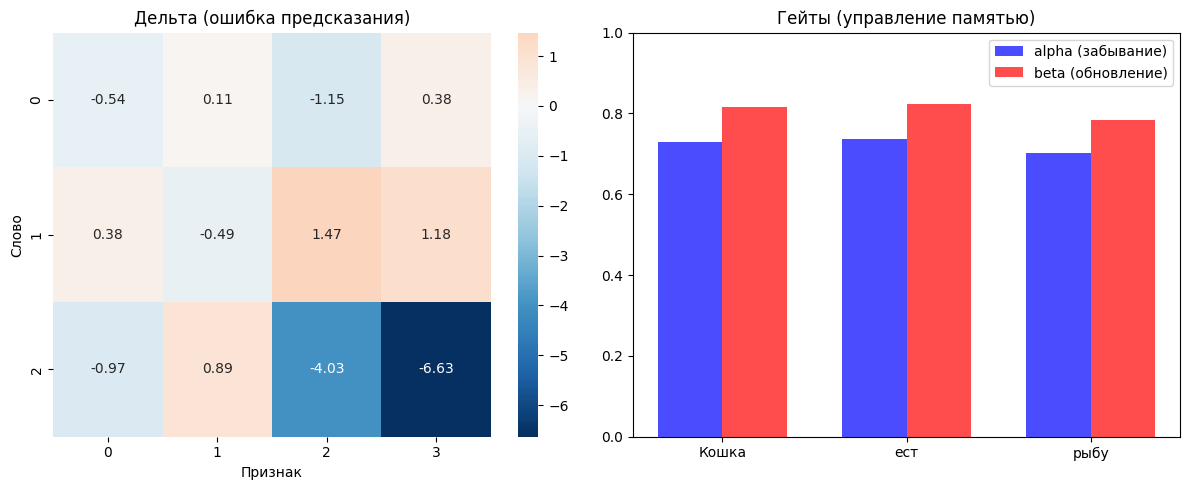

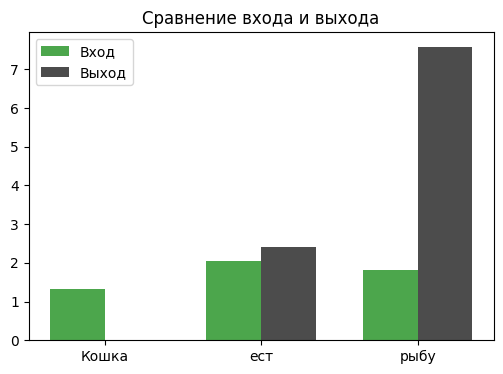

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def sigmoid(x): #Сигмоида — сжимает любое число в интервал (0, 1)
    # Формула: σ(x) = 1 / (1 + e^{-x})
    return 1 / (1 + np.exp(-x))


def gated_deltanet(Q, K, V):
    """
    Входные матрицы:
        
        K (Key)   — ключи: с чем сравниваем запросы 
        V (Value) — значения: что мы извлекаем при совпадении 
    """
    
    # Получаем размерность векторов
    d_k = Q.shape[-1]  # количество признаков у каждого слова
    n = Q.shape[0]     # количество слов в предложении

    # Создаём пустую матрицу памяти S размером (d_k × d_k)
    S = np.zeros((d_k, d_k))
    output = np.zeros_like(Q)
    
    # Создаём списки для сохранения промежуточных результатов (для визуализации)
    deltas_history = []      # история дельт (ошибок)
    gates_alpha_history = [] # история гейта забывания
    gates_beta_history = []  # история гейта обновления

    for i in range(n):
        # Берём данные для текущего слова 
        q_i = Q[i].reshape(-1, 1)  # запрос текущего слова (d_k × 1) -1 - автомат подсчет кол-ва слов, а 1 это одна колонка
        k_i = K[i].reshape(-1, 1)  # ключ текущего слова (d_k × 1)
        v_i = V[i].reshape(-1, 1)  # значение текущего слова (d_k × 1)
        
        # Умножаем память на запрос: получаем предсказание v_i
        prediction = S @ q_i  # (d_k × d_k) @ (d_k × 1) = (d_k × 1)

        # Сохраняем предсказание
        output[i] = prediction.flatten()
        
        # Вычисляем "дельту" (ошибку предсказания) 
        delta = v_i - prediction  

        # Используем норму q_i как меру "важности" текущего слова
        q_norm = np.linalg.norm(q_i)  
        
        # gate_alpha (забывание): сколько старой памяти забыть
        gate_alpha = sigmoid(q_norm / 3.0)  # число от 0 до 1 (0 все забываем, 1 ничего не забываем)
        
        
        # gate_beta (обновление): как сильно обновить память
        gate_beta = sigmoid(q_norm / 2.0)   # число от 0 до 1
        
        # Обновляем память по дельта-правилу
        S = S * gate_alpha + delta @ (k_i * gate_beta).T
        
        # Сохраняем историю для визуализации
        deltas_history.append(delta.flatten())
        gates_alpha_history.append(gate_alpha)
        gates_beta_history.append(gate_beta)
    
    return output, S, deltas_history, gates_alpha_history, gates_beta_history

np.random.seed(42)
seq_len = 3   # количество слов в предложении
d_k = 4       # размерность вектора каждого слова
words = ['Кошка', 'ест', 'рыбу']

Q = np.random.randn(seq_len, d_k)   # матрица запросов
K = np.random.randn(seq_len, d_k)   # матрица ключей
V = np.random.randn(seq_len, d_k)   # матрица значений

# Связь 1: "Кошка" (слово с индексом 0) должна смотреть на "ест" (слово 1)
# Делаем запрос "Кошки" (Q[0]) похожим на ключ "ест" (K[1])
# Умножаем на 1.5, чтобы связь была сильной (но не абсолютной)
Q[0] = K[1] * 1.5   # Кошка → ест

# Связь 2: "ест" (слово 1) должно смотреть на "рыбу" (слово 2)
# Запрос "ест" делаем похожим на ключ "рыбу"
Q[1] = K[2] * 1.5   # ест → рыбу

# Связь 3: "рыбу" (слово 2) смотрит на "ест" (слово 1)
# Запрос "рыбу" делаем похожим на ключ "ест"
Q[2] = K[1] * 1.3   # рыбу → ест


# вызываем функцию
output, memory_final, deltas, gates_alpha, gates_beta = gated_deltanet(Q, K, V)

print("\n1. Итоговая матрица памяти S (сжатый контекст ВСЕГО предложения):")
print(memory_final)

print("\n2. Выходные векторы (предсказания на основе контекста):")
print(output)

print("\n3. Значения дельт (ошибок предсказания) для каждого слова:")
for i, word in enumerate(words):
    print(f"  {word}: {np.linalg.norm(deltas[i]):.4f} (длина вектора ошибки)")

print("\n4. Значения гейтов:")
print("  (alpha — забывание: 1 = все помнить, 0 =  все забыть)")
print("  (beta — обновление: 1 = сильно обновить, 0 = не обновлять)")
for i, word in enumerate(words):
    print(f"  {word}: alpha={gates_alpha[i]:.3f}, beta={gates_beta[i]:.3f}")


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# График 1: Дельта (тепловая карта) 
sns.heatmap(deltas, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[0])
axes[0].set_title('Дельта (ошибка предсказания)')
axes[0].set_xlabel('Признак')
axes[0].set_ylabel('Слово')


# График 2: Гейты (группированные столбцы) 
x = np.arange(len(words))
width = 0.35

axes[1].bar(x - width/2, gates_alpha, width, alpha=0.7, label='alpha (забывание)', color='blue')
axes[1].bar(x + width/2, gates_beta, width, alpha=0.7, label='beta (обновление)', color='red')
axes[1].set_xticks(x)
axes[1].set_xticklabels(words)
axes[1].set_ylim(0, 1)
axes[1].set_title('Гейты (управление памятью)')
axes[1].legend()

plt.tight_layout()
plt.show()

# ГРАФИК 3: Сравнение входа и выхода

input_norms = np.linalg.norm(V, axis=1)
output_norms = np.linalg.norm(output, axis=1)

x = np.arange(len(words))
width = 0.35

plt.figure(figsize=(6, 4))
plt.bar(x - width/2, input_norms, width, label='Вход', alpha=0.7, color='green')
plt.bar(x + width/2, output_norms, width, label='Выход', alpha=0.7, color='black')
plt.xticks(x, words)
plt.title('Сравнение входа и выхода')
plt.legend()
plt.show()

